In [44]:
from langgraph.graph import StateGraph, START, MessagesState
from langchain_groq import ChatGroq
from dotenv import load_dotenv

In [45]:
!pip install langchain-groq



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [46]:
load_dotenv()
llm = ChatGroq(
    model = "llama-3.1-8b-instant",
    temperature=0.7
)

In [47]:
def call_model(state:MessagesState):
    response = llm.invoke(state["messages"])
    return {"messages":[response]}


In [48]:
builder = StateGraph(MessagesState)
builder.add_node("call_model", call_model)
builder.add_edge(START, "call_model")


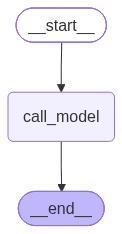

In [49]:
graph = builder.compile()
graph

In [50]:
graph.invoke({"messages": [ {"role":"user" , "content":"Hi!My name is Abdullah"}]})

{'messages': [HumanMessage(content='Hi!My name is Abdullah', additional_kwargs={}, response_metadata={}, id='c0f7f66b-27fe-4944-a912-3c8f2b17972a'),
  AIMessage(content='Nice to meet you, Abdullah. Is there something I can help you with or would you like to chat?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 23, 'prompt_tokens': 41, 'total_tokens': 64, 'completion_time': 0.023517683, 'completion_tokens_details': None, 'prompt_time': 0.003029348, 'prompt_tokens_details': None, 'queue_time': 0.053878827, 'total_time': 0.026547031}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019fdcad-7e36-7900-aa5a-0570f79ef87a-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 41, 'output_tokens': 23, 'total_tokens': 64})]}

In [51]:
graph.invoke({"messages":[{"role":"user" , "content":"What is my name?"}]})

{'messages': [HumanMessage(content='What is my name?', additional_kwargs={}, response_metadata={}, id='bbdd8321-b1dc-48d5-8e11-6b2d867bb999'),
  AIMessage(content="I don't have any information about your name. I'm a large language model, I don't have personal knowledge or memories, and I don't retain information about individual users. Each time you interact with me, it's a new conversation. If you'd like to share your name with me, I can use it to address you in our conversation.", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 72, 'prompt_tokens': 40, 'total_tokens': 112, 'completion_time': 0.086117746, 'completion_tokens_details': None, 'prompt_time': 0.002895069, 'prompt_tokens_details': None, 'queue_time': 0.051087445, 'total_time': 0.089012815}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019fdcad-8138-7cb2-

In [52]:
def call_model(state:MessagesState):
    response = llm.invoke(state["messages"])
    return{"messages":[response]}

In [53]:
builder = StateGraph(MessagesState)
builder.add_node("call_model", call_model)
builder.add_edge(START , "call_model")

In [54]:
from langgraph.checkpoint.memory import InMemorySaver
checkpointer = InMemorySaver()
graph = builder.compile(checkpointer=checkpointer)

In [55]:
config = {"configurable": {"thread_id": "thread-1"}}
config2 = {"configurable": {"thread_id": "thread-2"}}

In [56]:
graph.invoke({"messages":[{"role": "user" , "content": "Hi! my name is abdullah"}]} , config)

{'messages': [HumanMessage(content='Hi! my name is abdullah', additional_kwargs={}, response_metadata={}, id='ff79d674-d958-42e1-a5bb-b28415d5aea4'),
  AIMessage(content='Nice to meet you, Abdullah. How can I assist you today?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 15, 'prompt_tokens': 43, 'total_tokens': 58, 'completion_time': 0.020514804, 'completion_tokens_details': None, 'prompt_time': 0.003133078, 'prompt_tokens_details': None, 'queue_time': 0.053621236, 'total_time': 0.023647882}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019fdcad-831a-7641-b272-8ba72032a6bc-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 43, 'output_tokens': 15, 'total_tokens': 58})]}

In [57]:
graph.invoke({"messages":[{"role": "user" , "content": "what is my name?"}]} , config2)

{'messages': [HumanMessage(content='what is my name?', additional_kwargs={}, response_metadata={}, id='baab471d-93e4-47a4-8e68-8fcc0a82b079'),
  AIMessage(content="I don't have any information about your name as our conversation has just started. I'm happy to chat with you, though. What would you like to talk about?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 35, 'prompt_tokens': 40, 'total_tokens': 75, 'completion_time': 0.048953467, 'completion_tokens_details': None, 'prompt_time': 0.002951918, 'prompt_tokens_details': None, 'queue_time': 0.050512061, 'total_time': 0.051905385}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019fdcad-846d-7703-a05a-f9400ad8b7a1-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 40, 'output_tokens': 35, 'total_tokens': 75})]}

In [59]:
snap = graph.get_state(config)
vals = snap.values
for m in vals.get("messages", []):
    print("-" , type(m).__name__,":" , m.content)

- HumanMessage : Hi! my name is abdullah
- AIMessage : Nice to meet you, Abdullah. How can I assist you today?
